In [2]:
import os 
import torch
os.chdir("/home/mabarr/gnnexplainer/")
from grover_adapter import model_data_preparation, GROVERExplainer
os.chdir("/home/mabarr/TCruzi_pipeline/external/grover/")
from torch.utils.data import DataLoader
from grover.data import MolCollator
from grover.data import MoleculeDataset
from grover.model.models import GroverFinetuneTask
import os
os.chdir("/home/mabarr/TCruzi_pipeline/external/grover/")
from task.train import load_data
os.chdir("/home/mabarr/TCruzi_pipeline/")
from argparse import Namespace

args = Namespace(
    data_path="external/grover/solubility_data/solubility_data_categorized.csv",
    save_dir="model_nofeatures_category",
    checkpoint_dir = "model_nofeatures_category",
    checkpoint_paths = ["model_nofeatures_category/fold_0/model_0/model.pt"],
    dataset_type="classification",
    split_type="scaffold_balanced",
    split_sizes=[0.7, 0.15, 0.15],
    metric="accuracy",
    ensemble_size=1,
    num_folds=1,
    ffn_hidden_size=200,
    batch_size=1,
    epochs=60,
    init_lr=0.00015,
    self_attention=True,
    save_smiles_splits=True,
    use_wandb=True,
    wandb_entity="mariabar",
    num_workers=0,
    dropout=0.1,
    ffn_num_layers=1,
    features_path = None,
    max_data_size = None,
    use_compound_names = None,
    seed = 0,
    separate_test_path = None,
    separate_val_path = None,
    folds_file = None,
    val_fold_index = None,
    test_fold_index = None,
    features_scaling=False,
    bond_drop_rate = 0,
    no_cache = True,
    cuda = True,
    features_only=False,
    embedding_output_type = "atom",
)

debug = info = print
logger = None

model, data_loader = model_data_preparation(
    current_args=args, 
    checkpoint_path="/home/mabarr/TCruzi_pipeline/model_nofeatures_category/fold_0/model_0/model.pt",
    smiles = ["Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1"]
)
_, batch, features_batch, mask, targets = next(iter(data_loader))

model.eval()
batch_preds = model(batch, features_batch)
batch_preds

Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_v.act_func.weight".
Loading pretr

tensor([[0.9182]], grad_fn=<DivBackward0>)

In [3]:
import os 
import torch
os.chdir("/home/mabarr/gnnexplainer/")
from grover_adapter import model_data_preparation, GROVERExplainer
from torch.utils.data import DataLoader
from grover.data import MolCollator
from grover.data import MoleculeDataset
from grover.model.models import GroverFinetuneTask

model, data_loader = model_data_preparation(
    current_args=args, 
    checkpoint_path="/home/mabarr/TCruzi_pipeline/model_nofeatures_category/fold_0/model_0/model.pt",
    smiles = ["Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1"]
)

model.eval()

explainer = GROVERExplainer(
    model=model,
    node_mask_type="attributes",
    epochs=200,
    lr=0.01
)

_, batch, features_batch, mask, targets = next(iter(data_loader))
f_atoms, f_bonds, a2b, b2a, b2revb, a_scope, b_scope, a2a = batch

expl_result = explainer.forward(batch, features_batch)

Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_v.act_func.weight".
Loading pretr

100%|██████████| 200/200 [00:52<00:00,  3.84it/s]


In [25]:
expl_result.available_explanations
results = expl_result.get_available_results()
results["node_mask"]
results["edge_mask"]

tensor([0.9385, 0.0870, 0.0877, 0.0789, 0.9357, 0.9382, 0.0827, 0.0766, 0.0859,
        0.9364, 0.0785, 0.0887, 0.0788, 0.9406, 0.0870, 0.0810, 0.0853, 0.9400,
        0.0700, 0.0707, 0.9381, 0.0859, 0.9388, 0.9380, 0.0813, 0.0846, 0.0811,
        0.1577, 0.0806, 0.9336, 0.9354, 0.9401, 0.9386, 0.0685, 0.0835, 0.1067,
        0.0822, 0.0825, 0.0675, 0.9421, 0.0832, 0.0804, 0.0831, 0.0817, 0.0842,
        0.0794, 0.0764, 0.0768])

In [26]:
expl_result.get_undirected_edge_mask(reduction="max")

tensor([0.9385, 0.0877, 0.9382, 0.0827, 0.9364, 0.0887, 0.9406, 0.0870, 0.9400,
        0.0707, 0.9381, 0.9388, 0.0846, 0.1577, 0.9336, 0.9401, 0.9386, 0.1067,
        0.0825, 0.9421, 0.0832, 0.0831, 0.0842, 0.0768])

In [27]:
expl_result.check_bond_mapping(smiles="Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1")

True

In [28]:
expl_result.visualize_graph(smiles="Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1", path="test_mol.png")

In [29]:
def get_atom_feature_labels():

    labels = []

    labels += [
        f"atomic_num_{i}"
        for i in range(100)
    ]
    labels += ["atomic_num_unknown"]

    labels += [
        f"degree_{i}"
        for i in range(6)
    ]
    labels += ["degree_unknown"]

    labels += [
        "formal_charge_-1",
        "formal_charge_-2",
        "formal_charge_1",
        "formal_charge_2",
        "formal_charge_0",
        "formal_charge_unknown",
    ]

    labels += [
        "chiral_tag_0",
        "chiral_tag_1",
        "chiral_tag_2",
        "chiral_tag_3",
        "chiral_tag_unknown",
    ]

    labels += [
        f"num_Hs_{i}"
        for i in range(5)
    ]
    labels += ["num_Hs_unknown"]

    labels += [
        "hybridization_SP",
        "hybridization_SP2",
        "hybridization_SP3",
        "hybridization_SP3D",
        "hybridization_SP3D2",
        "hybridization_unknown",
    ]

    labels += [
        "aromatic",
        "mass",
    ]

    labels += [
        f"implicit_valence_{i}"
        for i in range(7)
    ]
    labels += ["implicit_valence_unknown"]

    labels += [
        "hydrogen_acceptor",
        "hydrogen_donor",
        "acidic",
        "basic",
        "ring_size_3",
        "ring_size_4",
        "ring_size_5",
        "ring_size_6",
        "ring_size_7",
        "ring_size_8",
    ]

    return labels


In [30]:
feat_labels = get_atom_feature_labels()

print(len(feat_labels))


151


In [31]:
expl_result.get_node_importance()

tensor([1.1296, 1.5786, 1.4105, 1.1556, 1.4456, 1.4910, 1.3059, 1.3231, 1.4780,
        1.4247, 1.3626, 1.4145, 1.2941, 1.6082, 1.4343, 1.2083, 1.3632, 1.4647,
        1.4489, 1.4752, 1.4138, 1.5110])

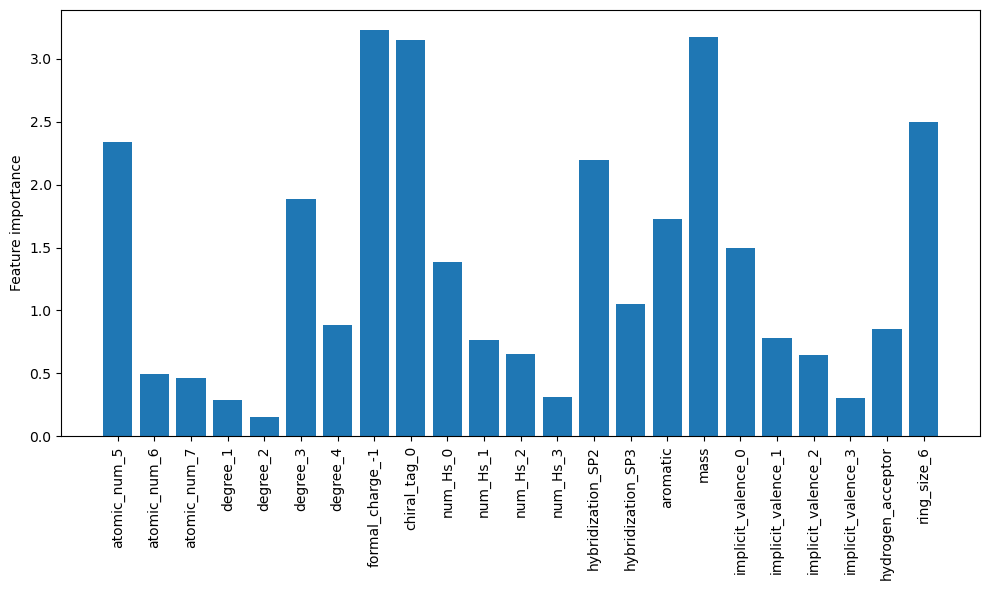

In [32]:
expl_result.visualize_feature_importance(feat_labels = feat_labels)